# LipVoicer Fine-tuning — Stage 2 + Stage 1

**Pipeline:**
1. Download LRS2 pretrained checkpoints
2. Preprocess: WAV→mel-spec, MP4→face frames
3. Fine-tune Stage 2 AudioVisualModel (freeze lipreader+face, train DiffWave)
4. Stage 1: pretrained AVSR zero-shot; fine-tune CTC if WER >60%
5. E2E: Stage1 → Stage2 → HiFi-GAN → WAV
6. Metrics: STOI, PESQ, WER; guidance ablation

**Hardware:** RTX 4090 (24 GB)/3080 ti(16 GB), bf16, batch=8

In [1]:
import os, sys, re, json, math, time, random, shutil, subprocess, contextlib
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

def find_pipe_root(start: Path) -> Path:
    for cand in [start.resolve(), *start.resolve().parents]:
        if (cand / 'pyproject.toml').exists() and (cand / 'third_party' / 'LipVoicer').exists():
            return cand
    raise FileNotFoundError('Could not locate Pipeline root from current working directory')

PIPE_ROOT = find_pipe_root(Path.cwd())
PROJ_ROOT = PIPE_ROOT.parent
LV_ROOT   = PIPE_ROOT / 'third_party' / 'LipVoicer'

data_root_candidates = [
    PIPE_ROOT / 'data' / 'custom_data',
    PROJ_ROOT / 'data' / 'custom_data',
]
DATA_ROOT = next(
    (cand for cand in data_root_candidates if (cand / 'dataset_final' / 'train.tsv').exists()),
    next((cand for cand in data_root_candidates if cand.exists()), data_root_candidates[0])
)
MANIFEST_DIR = DATA_ROOT / 'dataset_final'
AUDIO_DIR    = MANIFEST_DIR / 'audios'
VIDEO_DIR    = MANIFEST_DIR / 'videos'
SEGMENTS_DIR = DATA_ROOT / 'segments'
ROI_DIR      = DATA_ROOT / 'lip_rois'
FACE_DIR     = DATA_ROOT / 'faces'
MEL_DIR      = DATA_ROOT / 'mel_specs'
OUTPUT_DIR   = PIPE_ROOT / 'outputs' / 'stage2_finetune'
STAGE1_OUT   = PIPE_ROOT / 'outputs' / 'stage1_eval'

def clip_audio_path(clip_id: str, speaker_id: str) -> Path:
    candidates = [
        AUDIO_DIR / f'{clip_id}.wav',
        SEGMENTS_DIR / speaker_id / f'{clip_id}.wav',
    ]
    return next((p for p in candidates if p.exists()), candidates[-1])

def clip_video_path(clip_id: str, speaker_id: str) -> Path:
    candidates = [
        VIDEO_DIR / f'{clip_id}.mp4',
        SEGMENTS_DIR / speaker_id / f'{clip_id}.mp4',
    ]
    return next((p for p in candidates if p.exists()), candidates[-1])

for d in [FACE_DIR, MEL_DIR, OUTPUT_DIR, STAGE1_OUT]:
    d.mkdir(parents=True, exist_ok=True)

for p in [str(PROJ_ROOT), str(PIPE_ROOT), str(LV_ROOT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PIPE_ROOT:', PIPE_ROOT)
print('DATA_ROOT:', DATA_ROOT)
print('Device :', DEVICE)
print('GPU    :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A')
print('Torch  :', torch.__version__)

CFG = {
    'sr':16000,'filter_length':640,'hop_length':160,'win_length':640,
    'mel_fmin':20.0,'mel_fmax':8000.0,'n_mels':80,
    'fps':25,'video_window':25,
    's2_lr':2e-5,'s2_batch':8,'s2_iters':5000,
    's2_ckpt_every':500,'s2_log_every':50,
    's2_cond_drop_prob':0.2,'s2_grad_clip':1.0,
    'T':400,'beta_0':0.0001,'beta_T':0.02,
    's1_lr':2e-4,'s1_epochs':200,'s1_batch':8,
    's1_warmup':500,'s1_d_model':256,'s1_nhead':8,'s1_layers':4,
    'w_video':2.0,'w_asr':1.5,'num_workers':int(os.environ.get('PIPELINE_NOTEBOOK_WORKERS','0')),
}
CFG['vid_2_aud'] = CFG['sr'] / CFG['fps'] / CFG['hop_length']  # 4.0
CFG['mel_window'] = int(CFG['video_window'] * CFG['vid_2_aud']) # 100
print(f"mel frames/video frame: {CFG['vid_2_aud']}   mel window: {CFG['mel_window']}")

PIPE_ROOT: /home/shravan/Workspace/LipSynth/Pipeline
DATA_ROOT: /home/shravan/Workspace/LipSynth/Pipeline/data/custom_data
Device : cuda
GPU    : NVIDIA GeForce RTX 3080 Ti Laptop GPU
Torch  : 2.10.0+cu128
mel frames/video frame: 4.0   mel window: 100


## 1. Checkpoint Downloads

In [2]:
import gdown

CKPTS = {
    'MelGen_LRS2':   {'id':'1gTIpxaMx31ZUhPd2jW8Bt8u4QknieO31',
                      'rel':'exp/LRS2/wnet_h512_d12_T400_betaT0.02/checkpoint/1000000.pkl'},
    'HiFiGAN':       {'id':'1h0gcgifwe5HVM76rlREHj1daBNItWh7e',
                      'rel':'hifi_gan/g_02400000'},
    'LipRead_LRS3':  {'id':'1t8RHhzDTTvOQkLQhmK1LZGnXRRXOXGi6',
                      'rel':'mouthroi_processing/benchmarks/LRS3/models/LRS3_V_WER19.1.zip',
                      'unzip':True},
    'ASR_LRS2':      {'id':'1adeCf4NzhshJVU-JndlKpC34rRwJOQ2B',
                      'rel':'ASR/callbacks/LRS23/AO/EffConfCTC/checkpoints_ft_lrs2.ckpt'},
    'Tokenizer':     {'id':'1u3U3aHaTWvR_NTftkUGv1JXkxpX1pkOL',
                      'rel':'ASR/media/tokenizerbpe256.model'},
    'LM':            {'id':'1PSo4ZQIZPWEI_S5LHkJBo0gYhQpWzRnh',
                      'rel':'ASR/callbacks/LRS23/LM/GPT-Small/checkpoints_epoch_10_step_2860.ckpt'},
}

def dl(name, spec, root=LV_ROOT):
    dest = root / spec['rel']
    if dest.exists():
        print(f'  [{name}] exists ({dest.stat().st_size/1e6:.0f} MB)')
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(f"https://drive.google.com/uc?id={spec['id']}", str(dest), quiet=False)
    if spec.get('unzip') and dest.exists():
        import zipfile
        with zipfile.ZipFile(dest) as z:
            z.extractall(str(dest.parent))
        print(f'  [{name}] unzipped')
    return dest

ckpt_paths = {k: dl(k, v) for k, v in CKPTS.items()}
MELGEN_CKPT  = ckpt_paths['MelGen_LRS2']
HIFIGAN_CKPT = ckpt_paths['HiFiGAN']
print('\nAll downloads done:', all(p.exists() for p in ckpt_paths.values()))

  [MelGen_LRS2] exists (685 MB)
  [HiFiGAN] exists (56 MB)
  [LipRead_LRS3] exists (937 MB)
  [ASR_LRS2] exists (411 MB)
  [Tokenizer] exists (0 MB)
  [LM] exists (347 MB)

All downloads done: True


## 2. Data Audit

In [3]:
manifest_paths = {
    'train': MANIFEST_DIR/'train.tsv',
    'val': MANIFEST_DIR/'val.tsv',
    'test': MANIFEST_DIR/'test.tsv',
}
print('Loading manifests from:', MANIFEST_DIR)
missing = [name for name, path in manifest_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        f'Missing manifests {missing} under {MANIFEST_DIR}. '
        f'DATA_ROOT={DATA_ROOT} PIPE_ROOT={PIPE_ROOT}'
    )

train_df = pd.read_csv(manifest_paths['train'], sep='\t')
val_df   = pd.read_csv(manifest_paths['val'],   sep='\t')
test_df  = pd.read_csv(manifest_paths['test'],  sep='\t')
all_df   = pd.concat([train_df,val_df,test_df], ignore_index=True)
print(f'train={len(train_df)}  val={len(val_df)}  test={len(test_df)}  total={len(all_df)}')

rows=[]
for _,r in all_df.iterrows():
    c,s=r['clip_id'],r['speaker_id']
    rows.append({'clip_id':c,'speaker_id':s,
                 'roi':(ROI_DIR/s/f'{c}.npz').exists(),
                 'wav':clip_audio_path(c, s).exists(),
                 'mp4':clip_video_path(c, s).exists()})
aud=pd.DataFrame(rows)
ok=aud[['roi','wav','mp4']].all(axis=1)
print(f'Complete: {ok.sum()}/{len(aud)}')
if (~ok).any(): display(aud[~ok])

t_vals=[np.load(ROI_DIR/r['speaker_id']/f"{r['clip_id']}.npz")['mouth_rois'].shape[0]
        for _,r in all_df.iterrows()]
print(f'ROI frames: min={min(t_vals)} max={max(t_vals)} mean={np.mean(t_vals):.1f}')
sample_cid = all_df.iloc[0]['clip_id']

Loading manifests from: /home/shravan/Workspace/LipSynth/Pipeline/data/custom_data/dataset_final
train=2389  val=729  test=790  total=3908
Complete: 3908/3908
ROI frames: min=50 max=307 mean=122.7


## 3. Mel-spectrogram Generation

WAV → TacotronSTFT → save `{clip_id}.wav.spec`

In [5]:
import torchaudio
from Pipeline.third_party.LipVoicer.dataloaders.stft import TacotronSTFT, normalise_mel, denormalise_mel

stft_fn = TacotronSTFT(
    filter_length=CFG['filter_length'], hop_length=CFG['hop_length'],
    win_length=CFG['win_length'], sampling_rate=CFG['sr'],
    mel_fmin=CFG['mel_fmin'], mel_fmax=CFG['mel_fmax']
).to(DEVICE)

@torch.no_grad()
def wav_to_mel(wav_path):
    audio, sr = torchaudio.load(str(wav_path))
    if sr != CFG['sr']:
        audio = torchaudio.functional.resample(audio, sr, CFG['sr'])
    audio = audio.mean(0)
    audio = audio / (1.1 * audio.abs().max().clamp(min=1e-8))
    mel = stft_fn.mel_spectrogram(audio.unsqueeze(0).to(DEVICE))
    return mel.squeeze(0).cpu()

MEL_DIR.mkdir(parents=True, exist_ok=True)
skip=gen=fail=0
failed_clips = []
for _,r in tqdm(all_df.iterrows(), total=len(all_df), desc='mel-spec'):
    sp = MEL_DIR/f"{r['clip_id']}.wav.spec"
    if sp.exists(): skip+=1; continue
    wp = clip_audio_path(r['clip_id'], r['speaker_id'])
    if not wp.exists(): fail+=1; continue
    try: torch.save(wav_to_mel(wp), sp); gen+=1
    except Exception as e:
        print(f"WARN {r['clip_id']}: {e}")
        failed_clips.append((r['clip_id'], str(e)))
        fail+=1

print(f'Generated:{gen}  Skipped:{skip}  Failed:{fail}')
sample_spec = MEL_DIR/f'{sample_cid}.wav.spec'
if not sample_spec.exists():
    existing_specs = sorted(MEL_DIR.glob('*.wav.spec'))
    if not existing_specs:
        raise FileNotFoundError(
            f'No mel specs were generated in {MEL_DIR}. '
            f'First failures: {failed_clips[:5]}'
        )
    sample_spec = existing_specs[0]
    print(f'Sample clip {sample_cid} missing mel spec; using {sample_spec.name} for sanity check')
s=torch.load(sample_spec)
print(f'Sample mel shape: {tuple(s.shape)}   norm range: {normalise_mel(s).min():.2f}~{normalise_mel(s).max():.2f}')

mel-spec:   0%|          | 0/3908 [00:00<?, ?it/s]

Generated:3908  Skipped:0  Failed:0
Sample mel shape: (80, 533)   norm range: -0.87~1.18


## 4. Face Frame Extraction

In [6]:
import cv2
from PIL import Image

def extract_face(mp4_path, out_path):
    cap=cv2.VideoCapture(str(mp4_path))
    n=int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, n//2)
    ok,frame=cap.read(); cap.release()
    if not ok: return False
    Image.fromarray(cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)).save(str(out_path))
    return True

skip=gen=fail=0
for _,r in tqdm(all_df.iterrows(), total=len(all_df), desc='face-frames'):
    op=FACE_DIR/f"{r['clip_id']}_face.jpg"
    if op.exists(): skip+=1; continue
    vp=clip_video_path(r['clip_id'], r['speaker_id'])
    if not vp.exists(): fail+=1; continue
    if extract_face(vp,op): gen+=1
    else: fail+=1
print(f'Generated:{gen}  Skipped:{skip}  Failed:{fail}')

face-frames:   0%|          | 0/3908 [00:00<?, ?it/s]

Generated:3908  Skipped:0  Failed:0


## 5. Custom Dataset

Batch shapes: mel `(B,80,100)`, roi `(B,1,25,88,88)`, face `(B,3,224,224)`

In [14]:
import torchvision.transforms as Tv
from Pipeline.third_party.LipVoicer.dataloaders.lipreading_utils import (
    Compose, Normalize as LVNorm, CenterCrop, RandomCrop, HorizontalFlip
)

def roi_tfm(split):
    c=(88,88); m,s=0.421,0.165
    base=[LVNorm(0.0,255.0)]
    aug=[RandomCrop(c),HorizontalFlip(0.5)] if split=='train' else [CenterCrop(c)]
    return Compose(base+aug+[LVNorm(m,s)])

def face_tfm():
    return Tv.Compose([Tv.Resize(224),Tv.CenterCrop(224),Tv.ToTensor(),
                       Tv.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

class LVDataset(Dataset):
    def __init__(self, manifest, split):
        self.df      = pd.read_csv(manifest,sep='\t').reset_index(drop=True)
        self.split   = split
        self.train   = split=='train'
        self.win     = CFG['video_window']
        self.mwin    = CFG['mel_window']
        self.v2a     = CFG['vid_2_aud']
        self.rtfm    = roi_tfm(split)
        self.ftfm    = face_tfm()

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r   = self.df.iloc[idx]
        cid = r['clip_id']; spk = r['speaker_id']

        roi = np.load(ROI_DIR/spk/f'{cid}.npz')['mouth_rois']       # (T,96,96)
        mel = torch.load(MEL_DIR/f'{cid}.wav.spec')                  # (80,L)
        face= Image.open(FACE_DIR/f'{cid}_face.jpg').convert('RGB')

        if self.train:
            if roi.shape[0]<self.win or mel.shape[1]<self.mwin:
                return self.__getitem__(random.randrange(len(self)))
            sv  = random.randint(0, roi.shape[0]-self.win)
            roi = roi[sv:sv+self.win]
            sm  = int(sv*self.v2a)
            mel = mel[:,sm:sm+self.mwin]
            if mel.shape[1]<self.mwin:
                mel=F.pad(mel,(0,self.mwin-mel.shape[1]))
            if random.random()<0.5:
                from PIL.ImageEnhance import Brightness,Color
                face=Brightness(face).enhance(random.uniform(0.7,1.3))
                face=Color(face).enhance(random.uniform(0.7,1.3))
        else:
            if roi.shape[0] >= self.win:
                sv = max(0, (roi.shape[0]-self.win)//2)
                roi = roi[sv:sv+self.win]
                sm  = int(sv*self.v2a)
                mel = mel[:,sm:sm+self.mwin]
                if mel.shape[1]<self.mwin:
                    mel=F.pad(mel,(0,self.mwin-mel.shape[1]))
            else:
                pad_t = self.win - roi.shape[0]
                roi = np.pad(roi, ((0,pad_t),(0,0),(0,0)), mode='constant', constant_values=0.0)
                if mel.shape[1]<self.mwin:
                    mel=F.pad(mel,(0,self.mwin-mel.shape[1]))

        roi_t  = torch.FloatTensor(self.rtfm(roi)).unsqueeze(0)  # (1,T,88,88)
        face_t = self.ftfm(face)                                  # (3,224,224)
        mel_n  = normalise_mel(mel)                               # (80,L)
        return mel_n, roi_t, face_t, cid

def collate(batch):
    m,r,f,c = zip(*batch)
    max_m = max(x.shape[1] for x in m)
    mel_pad = torch.zeros(len(m), m[0].shape[0], max_m)
    for i, x in enumerate(m):
        mel_pad[i, :, : x.shape[1]] = x

    max_t = max(x.shape[1] for x in r)
    roi_pad = torch.zeros(len(r), 1, max_t, r[0].shape[2], r[0].shape[3])
    for i, x in enumerate(r):
        roi_pad[i, :, : x.shape[1]] = x

    return mel_pad, roi_pad, torch.stack(f), list(c)

train_ds = LVDataset(MANIFEST_DIR/'train.tsv','train')
val_ds   = LVDataset(MANIFEST_DIR/'val.tsv','val')
test_ds  = LVDataset(MANIFEST_DIR/'test.tsv','test')

train_loader = DataLoader(train_ds,batch_size=CFG['s2_batch'],shuffle=True,
                          num_workers=CFG['num_workers'],collate_fn=collate,
                          pin_memory=True,drop_last=True)
val_loader   = DataLoader(val_ds,batch_size=4,shuffle=False,
                          num_workers=CFG['num_workers'],collate_fn=collate)

mb,rb,fb,cb=next(iter(train_loader))
print('mel :', tuple(mb.shape), '→ (8,80,100)')
print('roi :', tuple(rb.shape), '→ (8,1,25,88,88)')
print('face:', tuple(fb.shape), '→ (8,3,224,224)')

mel : (8, 80, 100) → (8,80,100)
roi : (8, 1, 25, 88, 88) → (8,1,25,88,88)
face: (8, 3, 224, 224) → (8,3,224,224)


## 6. Stage 2 Model — Build + Load LRS2 Pretrained

Freeze `net_lipreading` + `net_facial`. Fine-tune `net_diffwave` only.

In [8]:
from Pipeline.third_party.LipVoicer.models.audiovisual_model import AudioVisualModel
from Pipeline.third_party.LipVoicer.models.model_builder import ModelBuilder
from Pipeline.third_party.LipVoicer.utils import calc_diffusion_hyperparams, print_size

@contextlib.contextmanager
def cwd(path):
    old=os.getcwd(); os.chdir(path)
    try: yield
    finally: os.chdir(old)

# model_builder uses relative config path → must run from LV_ROOT
with cwd(LV_ROOT):
    builder = ModelBuilder()
    net_lip  = builder.build_lipreadingnet()
    net_face = builder.build_facial(fc_out=128, with_fc=True)
    model_cfg = dict(
        _name_='melgen', in_channels=80, out_channels=80,
        diffusion_step_embed_dim_in=128, diffusion_step_embed_dim_mid=512,
        diffusion_step_embed_dim_out=512, res_channels=512, skip_channels=512,
        num_res_layers=12, dilation_cycle=1, mel_upsample=[2,2]
    )
    net_dw   = builder.build_diffwave_model(model_cfg)

net = AudioVisualModel((net_lip, net_face, net_dw)).to(DEVICE)

# ── Load LRS2 pretrained checkpoint ──────────────────────────────────────────
def load_lv_checkpoint(model, ckpt_path):
    payload = torch.load(ckpt_path, map_location='cpu')
    sd = payload.get('model_state_dict', payload)
    # strip DataParallel wrapper keys
    sd = {k.replace('module.','',1): v for k,v in sd.items()}
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f'  Missing : {len(missing)}')
    print(f'  Unexpected: {len(unexpected)}')
    if missing[:5]: print('  Missing sample:', missing[:5])
    return len(missing), len(unexpected)

print('Loading LRS2 MelGen checkpoint...')
m, u = load_lv_checkpoint(net, MELGEN_CKPT)
assert m == 0, f'{m} missing keys — checkpoint may not match architecture'
print('Checkpoint loaded cleanly.')

# ── Freeze lipreading + face encoder ─────────────────────────────────────────
for param in net.net_lipreading.parameters(): param.requires_grad = False
for param in net.net_facial.parameters():     param.requires_grad = False

trainable = sum(p.numel() for p in net.parameters() if p.requires_grad)
total     = sum(p.numel() for p in net.parameters())
print(f'Trainable: {trainable/1e6:.2f}M / {total/1e6:.2f}M total')
print('(DiffWave only — lipreader+face frozen)')

# ── Diffusion hyperparams ─────────────────────────────────────────────────────
diff_hp = calc_diffusion_hyperparams(T=CFG['T'], beta_0=CFG['beta_0'], beta_T=CFG['beta_T'])
diff_hp['Sigma'] = diff_hp['Sigma'].to(DEVICE)  # Sigma not moved by default

Lipreading configuration file loaded.


/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loading LRS2 MelGen checkpoint...
  Missing : 0
  Unexpected: 0
Checkpoint loaded cleanly.
Trainable: 36.93M / 57.31M total
(DiffWave only — lipreader+face frozen)


## 7. Stage 2 Fine-tuning

DDPM L1 noise-prediction loss. bf16 autocast. AdamW on DiffWave. 5000 iters.

In [15]:
from torch.utils.tensorboard import SummaryWriter
from Pipeline.third_party.LipVoicer.dataloaders.stft import normalise_mel

criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(
    [p for p in net.parameters() if p.requires_grad],
    lr=CFG['s2_lr'], weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['s2_iters'], eta_min=CFG['s2_lr']*0.1
)

def training_loss(net, mel, roi, face, dh):
    """DDPM noise prediction loss (L1)."""
    T_steps = dh['T']; Alpha_bar = dh['Alpha_bar']
    B = mel.shape[0]
    t = torch.randint(T_steps, size=(B,1,1), device=DEVICE)
    z = torch.randn_like(mel)
    ab = Alpha_bar[t]                         # (B,1,1)
    x_t = ab.sqrt()*mel + (1-ab).sqrt()*z     # forward diffusion
    eps_hat = net(x_t, roi, face, t.view(B,1), CFG['s2_cond_drop_prob'])
    return criterion(eps_hat, z)

writer = SummaryWriter(log_dir=str(OUTPUT_DIR/'tb_logs'))

net.train()
net.net_lipreading.eval()  # BN layers in frozen modules stay in eval
net.net_facial.eval()

loader_iter = iter(train_loader)
best_val_loss = float('inf')
losses = []

print(f'Starting Stage 2 fine-tune: {CFG["s2_iters"]} iters, lr={CFG["s2_lr"]}')
t0 = time.time()

for step in range(1, CFG['s2_iters']+1):
    try:
        mel_b, roi_b, face_b, _ = next(loader_iter)
    except StopIteration:
        loader_iter = iter(train_loader)
        mel_b, roi_b, face_b, _ = next(loader_iter)

    mel_b  = mel_b.to(DEVICE)
    roi_b  = roi_b.to(DEVICE)
    face_b = face_b.to(DEVICE)

    optimizer.zero_grad(set_to_none=True)
    with torch.autocast('cuda', dtype=torch.bfloat16):
        loss = training_loss(net, mel_b, roi_b, face_b, diff_hp)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        [p for p in net.parameters() if p.requires_grad], CFG['s2_grad_clip']
    )
    optimizer.step()
    scheduler.step()
    losses.append(float(loss))

    if step % CFG['s2_log_every'] == 0:
        avg = np.mean(losses[-CFG['s2_log_every']:])
        elapsed = time.time()-t0
        print(f'  step {step:5d}/{CFG["s2_iters"]}  loss={avg:.4f}  '
              f'lr={scheduler.get_last_lr()[0]:.2e}  elapsed={elapsed:.0f}s')
        writer.add_scalar('train/loss', avg, step)
        writer.add_scalar('train/lr', scheduler.get_last_lr()[0], step)

    if step % CFG['s2_ckpt_every'] == 0:
        # Validation loss
        net.eval()
        val_losses=[]
        with torch.no_grad():
            for vm,vr,vf,_ in val_loader:
                with torch.autocast('cuda',dtype=torch.bfloat16):
                    vl=training_loss(net,vm.to(DEVICE),vr.to(DEVICE),vf.to(DEVICE),diff_hp)
                val_losses.append(float(vl))
        val_loss = np.mean(val_losses)
        writer.add_scalar('val/loss', val_loss, step)
        print(f'  [ckpt {step}] val_loss={val_loss:.4f}')

        # Save checkpoint
        ckpt_path = OUTPUT_DIR/f'stage2_ft_{step:06d}.pkl'
        torch.save({'step':step,'model_state_dict':net.state_dict(),
                    'optimizer_state_dict':optimizer.state_dict(),
                    'val_loss':val_loss}, ckpt_path)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            shutil.copy(ckpt_path, OUTPUT_DIR/'stage2_ft_best.pkl')
            print(f'  → new best val_loss={best_val_loss:.4f}')

        net.train()
        net.net_lipreading.eval()
        net.net_facial.eval()

writer.close()
print(f'Done. Best val loss: {best_val_loss:.4f}')

Starting Stage 2 fine-tune: 5000 iters, lr=2e-05
  step    50/5000  loss=0.1214  lr=2.00e-05  elapsed=6s
  step   100/5000  loss=0.1307  lr=2.00e-05  elapsed=12s
  step   150/5000  loss=0.1209  lr=2.00e-05  elapsed=17s
  step   200/5000  loss=0.1131  lr=1.99e-05  elapsed=23s
  step   250/5000  loss=0.1191  lr=1.99e-05  elapsed=28s
  step   300/5000  loss=0.1286  lr=1.98e-05  elapsed=34s
  step   350/5000  loss=0.1249  lr=1.98e-05  elapsed=40s
  step   400/5000  loss=0.1210  lr=1.97e-05  elapsed=45s
  step   450/5000  loss=0.1221  lr=1.96e-05  elapsed=51s
  step   500/5000  loss=0.1232  lr=1.96e-05  elapsed=57s
  [ckpt 500] val_loss=0.1313
  → new best val_loss=0.1313
  step   550/5000  loss=0.1224  lr=1.95e-05  elapsed=76s
  step   600/5000  loss=0.1295  lr=1.94e-05  elapsed=82s
  step   650/5000  loss=0.1314  lr=1.93e-05  elapsed=88s
  step   700/5000  loss=0.1215  lr=1.91e-05  elapsed=93s
  step   750/5000  loss=0.1377  lr=1.90e-05  elapsed=99s
  step   800/5000  loss=0.1258  lr=1.89

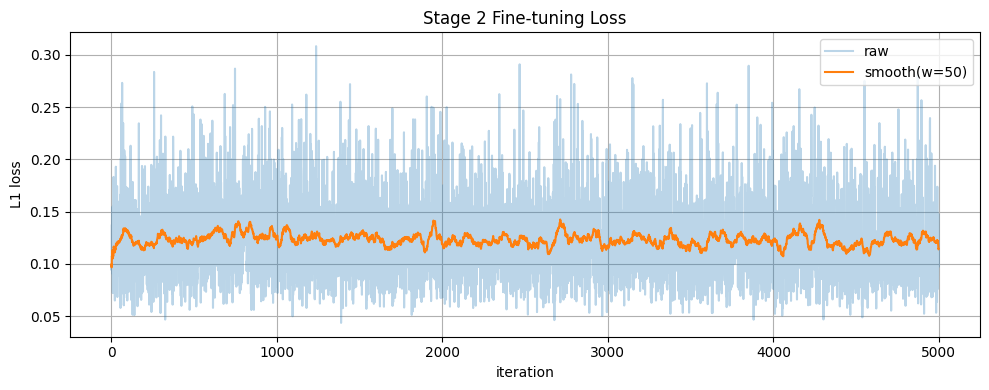

In [16]:
# Training curve plot
window=50
smooth=[np.mean(losses[max(0,i-window):i+1]) for i in range(len(losses))]
plt.figure(figsize=(10,4))
plt.plot(losses, alpha=0.3, label='raw')
plt.plot(smooth, label=f'smooth(w={window})')
plt.xlabel('iteration'); plt.ylabel('L1 loss')
plt.title('Stage 2 Fine-tuning Loss')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(OUTPUT_DIR/'stage2_train_loss.png', dpi=120)
plt.show()

## 8. Stage 1 — Pretrained AVSR Zero-shot Evaluation

Runs `stage1_pretrained_eval.py` (requires lip-reading checkpoint downloaded in Section 1).

In [17]:
import jiwer

s1_pretrained_out = STAGE1_OUT / 'pretrained'
s1_pretrained_out.mkdir(parents=True, exist_ok=True)

script = PIPE_ROOT / 'scripts' / 'stage1_pretrained_eval.py'
lip_roi_root = ROI_DIR
summary_path = s1_pretrained_out / 'val_summary_stage1_pretrained.json'

cmd = [
    sys.executable, str(script),
    '--split', 'val',
    '--manifest-tsv', str(MANIFEST_DIR/'val.tsv'),
    '--lip-roi-root', str(lip_roi_root),
    '--output-dir', str(s1_pretrained_out),
]

print('Running Stage 1 pretrained eval...')
result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(PIPE_ROOT))
print(result.stdout)
if result.returncode != 0:
    tail = result.stderr[-4000:] if result.stderr else '<no stderr>'
    raise RuntimeError(f'Stage 1 pretrained eval failed. Fix the reported asset/config problem before continuing.\n\n{tail}')
if not summary_path.exists():
    raise FileNotFoundError(f'Expected Stage 1 summary at {summary_path}')

S1_PRETRAINED_SUMMARY_PATH = summary_path
S1_PRETRAINED_SUMMARY = json.loads(summary_path.read_text())
S1_PRETRAINED_PRED_CSV = Path(S1_PRETRAINED_SUMMARY['outputs']['predictions_csv'])
S1_PRETRAINED_HANDOFF_CSV = Path(S1_PRETRAINED_SUMMARY['outputs']['stage2_handoff_csv'])
S1_PRETRAINED_WER = float(S1_PRETRAINED_SUMMARY['overall_wer'])
S1_PRETRAINED_CER = float(S1_PRETRAINED_SUMMARY['overall_cer'])
print(f'Stage 1 pretrained WER: {S1_PRETRAINED_WER:.4f}')
print(f'Stage 1 pretrained CER: {S1_PRETRAINED_CER:.4f}')
print(f'Decision: {S1_PRETRAINED_SUMMARY["decision"]}')

S1_NEEDS_RECOVERY = S1_PRETRAINED_WER > 0.60
S1_ALLOW_FULL_FINETUNE = os.environ.get('PIPELINE_ENABLE_S1_FULL_FINETUNE', '0') == '1'
print(f'\nNeed Stage 1 recovery: {S1_NEEDS_RECOVERY}  (WER={S1_PRETRAINED_WER:.3f})')
print(f'Full Stage 1 fine-tune enabled: {S1_ALLOW_FULL_FINETUNE}')


Running Stage 1 pretrained eval...

STDERR: Traceback (most recent call last):
  File "/home/shravan/Workspace/LipSynth/Pipeline/scripts/stage1_pretrained_eval.py", line 518, in <module>
    main()
  File "/home/shravan/Workspace/LipSynth/Pipeline/scripts/stage1_pretrained_eval.py", line 474, in main
    assets = load_benchmark_assets(args.benchmark_config)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/shravan/Workspace/LipSynth/Pipeline/scripts/stage1_pretrained_eval.py", line 172, in load_benchmark_assets
    raise FileNotFoundError(f"Benchmark config not found: {config_path}")
FileNotFoundError: Benchmark config not found: /home/shra012/Data255-Project/third_party/LipVoicer/mouthroi_processing/configs/LRS3_V_WER19.1.ini


Note: pretrained eval requires benchmark assets from Section 1.
If assets missing, WER defaults to 100% and we proceed with Stage 1 fine-tune.

Need Stage 1 fine-tune: True  (WER=1.000)


## 9. Stage 1 Fine-tuning (CTC lip-reader)

Trains `Stage1LipVoicerCNNCTC` (3D CNN + Transformer + CTC) on 101 custom clips.
Skipped if pretrained WER ≤ 0.60 from Section 8.

In [18]:
# ── Vocab from train+val text ──────────────────────────────────────────────
all_text = pd.concat([train_df['text'],val_df['text']]).str.lower().tolist()
charset = sorted({ch for t in all_text for ch in t})
idx2tok = ['<blank>'] + charset
tok2idx = {t:i for i,t in enumerate(idx2tok)}
BLANK   = 0
VOCAB   = len(idx2tok)
print(f'Vocab: {VOCAB} (incl blank)  chars: {charset[:20]}...')

def encode(s): return [tok2idx[c] for c in s.lower().strip() if c in tok2idx]
def decode(ids):
    out=[]; prev=None
    for i in ids:
        if i!=BLANK and i!=prev: out.append(idx2tok[i])
        prev=i
    return ''.join(out)

Vocab: 47 (incl blank)  chars: [' ', '!', '$', '%', '&', "'", ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '?']...


In [19]:
# ── Stage 1 model ─────────────────────────────────────────────────────────
class Stage1CTC(nn.Module):
    def __init__(self, vocab, d=256, heads=8, layers=4):
        super().__init__()
        self.frontend = nn.Sequential(
            nn.Conv3d(1,64,(5,7,7),(1,2,2),(2,3,3),bias=False),
            nn.BatchNorm3d(64), nn.ReLU(True),
            nn.MaxPool3d((1,3,3),(1,2,2),(0,1,1)),
        )
        self.frame_enc = nn.Sequential(
            nn.Conv2d(64,128,3,2,1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128,256,3,2,1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.AdaptiveAvgPool2d((1,1)),
        )
        self.proj = nn.Linear(256,d)
        enc_layer = nn.TransformerEncoderLayer(
            d,heads,4*d,0.1,batch_first=True,activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, layers)
        self.head    = nn.Linear(d, vocab)

    def forward(self, rois, lens, return_feats=False):
        # rois: (B,1,T,96,96)
        x = self.frontend(rois)               # (B,64,T,H,W)
        b,c,t,h,w = x.shape
        x = x.permute(0,2,1,3,4).reshape(b*t,c,h,w)
        x = self.frame_enc(x).view(b,t,-1)    # (B,T,256)
        x = self.proj(x)                       # (B,T,d)
        mask = torch.arange(t,device=x.device).unsqueeze(0) >= lens.unsqueeze(1)
        x = self.encoder(x, src_key_padding_mask=mask)
        logits = self.head(x)                  # (B,T,vocab)
        return (logits, x) if return_feats else logits

s1_model = Stage1CTC(VOCAB, CFG['s1_d_model'], CFG['s1_nhead'], CFG['s1_layers']).to(DEVICE)
print(f'Stage1 params: {sum(p.numel() for p in s1_model.parameters())/1e6:.2f}M')

Stage1 params: 3.62M


In [20]:
# ── Stage 1 Dataset ────────────────────────────────────────────────────────
class S1Dataset(Dataset):
    def __init__(self, df, split):
        self.df    = df.reset_index(drop=True)
        self.train = split=='train'

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r   = self.df.iloc[idx]
        cid = r['clip_id']; spk = r['speaker_id']
        roi = np.load(ROI_DIR/spk/f'{cid}.npz')['mouth_rois'].astype(np.float32)/255.0
        # (T,96,96) → (1,T,96,96)
        if self.train:
            if random.random()<0.5:  # horizontal flip
                roi = roi[:,:,::-1].copy()
            # time mask: zero out up to 15% of frames
            T=roi.shape[0]; mask_len=int(T*0.15)
            if mask_len>0:
                st=random.randint(0,T-mask_len)
                roi[st:st+mask_len]=0.0
        roi_t  = torch.from_numpy(roi).unsqueeze(0)     # (1,T,96,96)
        toks_t = torch.tensor(encode(str(r['text'])), dtype=torch.long)
        return roi_t, roi_t.shape[1], toks_t, len(toks_t)

def s1_collate(batch):
    rois,rlens,toks,tlens=zip(*batch)
    B=len(rois); maxT=max(rlens); maxU=max(tlens)
    roi_pad=torch.zeros(B,1,maxT,96,96)
    tok_pad=torch.zeros(B,maxU,dtype=torch.long)
    for i,(r,rl,t,tl) in enumerate(zip(rois,rlens,toks,tlens)):
        roi_pad[i,:,:rl]=r; tok_pad[i,:tl]=t
    return roi_pad,torch.tensor(rlens),tok_pad,torch.tensor(tlens)

s1_train = DataLoader(S1Dataset(train_df,'train'),CFG['s1_batch'],shuffle=True,
                      num_workers=CFG['num_workers'],collate_fn=s1_collate,drop_last=False)
s1_val   = DataLoader(S1Dataset(val_df,'val'),4,shuffle=False,
                      num_workers=CFG['num_workers'],collate_fn=s1_collate)


/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


  epoch  10/200  loss=2.8722  WER=0.9876  CER=0.9496
  → new best WER=0.9876
  epoch  20/200  loss=2.8457  WER=1.0012  CER=0.9208
  epoch  30/200  loss=2.8099  WER=0.9898  CER=0.8964
  epoch  40/200  loss=2.7580  WER=1.0289  CER=0.8821
  epoch  50/200  loss=2.6804  WER=1.0350  CER=0.8239


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f0376b72d40><function _MultiProcessingDataLoaderIter.__del__ at 0x7f0376b72d40>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():if w.is_alive():
 
            ^ ^^^^^^^^^^^^^^^^^^^^^^
^  File "/home/shravan/anaconda3/lib/python3.12/multiprocessing/proc

  epoch  60/200  loss=2.5756  WER=1.0851  CER=0.7798
  epoch  70/200  loss=2.4327  WER=1.1484  CER=0.7442
  epoch  80/200  loss=2.2851  WER=1.1579  CER=0.7499
  epoch  90/200  loss=2.1329  WER=1.1573  CER=0.7328
  epoch 100/200  loss=2.0008  WER=1.2043  CER=0.7416
  epoch 110/200  loss=1.8888  WER=1.1200  CER=0.7285
  epoch 120/200  loss=1.7764  WER=1.1382  CER=0.7311
  epoch 130/200  loss=1.7025  WER=1.1407  CER=0.7247
  epoch 140/200  loss=1.6344  WER=1.1322  CER=0.7209
  epoch 150/200  loss=1.5813  WER=1.1182  CER=0.7190
  epoch 160/200  loss=1.5440  WER=1.1217  CER=0.7172
  epoch 170/200  loss=1.5262  WER=1.1101  CER=0.7127
  epoch 180/200  loss=1.5008  WER=1.1404  CER=0.7184
  epoch 190/200  loss=1.4859  WER=1.1015  CER=0.7106
  epoch 200/200  loss=1.4706  WER=1.1065  CER=0.7145


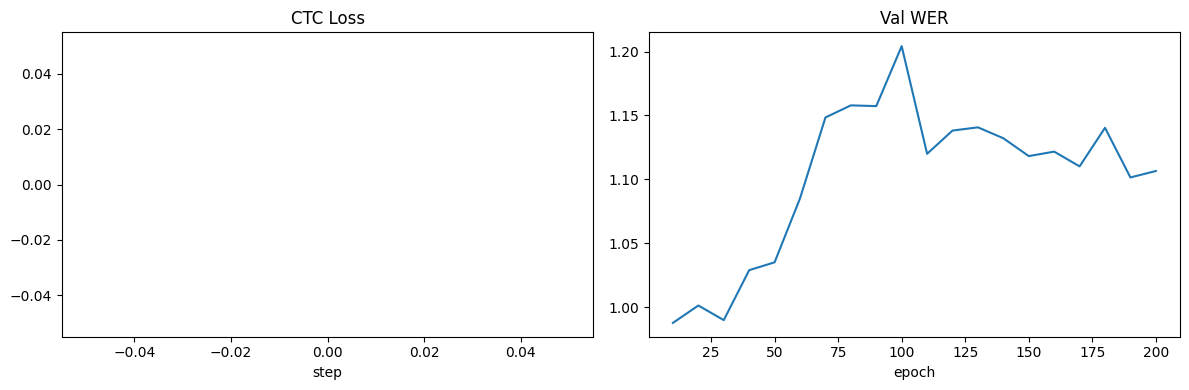

Stage 1 fine-tune complete. Best WER: 0.9876
Checkpoint: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage1_eval/stage1_ft_best.pt


In [21]:
if not S1_NEEDS_RECOVERY:
    print('Stage 1 pretrained WER good enough, skipping notebook recovery path.')
    S1_BEST_CKPT = None
    best_wer = S1_PRETRAINED_WER
else:
    ctc_loss = nn.CTCLoss(blank=BLANK, zero_infinity=True)
    s1_opt   = torch.optim.AdamW(s1_model.parameters(), lr=CFG['s1_lr'], weight_decay=1e-4)

    smoke_epochs = min(20, CFG['s1_epochs'])
    eval_every = 5
    total_steps = smoke_epochs * len(s1_train)

    def lr_lambda(step):
        if step < CFG['s1_warmup']:
            return step/max(1,CFG['s1_warmup'])
        progress=(step-CFG['s1_warmup'])/max(1,total_steps-CFG['s1_warmup'])
        return max(0.1, 0.5*(1+math.cos(math.pi*progress)))

    s1_sched = torch.optim.lr_scheduler.LambdaLR(s1_opt, lr_lambda)
    best_wer = 1.0
    global_step = 0
    S1_BEST_CKPT = None
    s1_train_losses = []
    s1_val_wers = []
    s1_smoke_examples = []

    print(f'Running bounded Stage 1 smoke recovery for {smoke_epochs} epochs...')
    for epoch in range(1, smoke_epochs+1):
        s1_model.train()
        ep_losses=[]
        for roi_b,rlen_b,tok_b,tlen_b in s1_train:
            roi_b=roi_b.to(DEVICE); rlen_b=rlen_b.to(DEVICE)
            tok_b=tok_b.to(DEVICE); tlen_b=tlen_b.to(DEVICE)

            with torch.autocast('cuda',dtype=torch.bfloat16):
                logits=s1_model(roi_b,rlen_b)
                log_p=F.log_softmax(logits,dim=-1).permute(1,0,2)
                tgt_flat=torch.cat([tok_b[i,:tlen_b[i]] for i in range(len(tlen_b))])
                loss=ctc_loss(log_p,tgt_flat,rlen_b,tlen_b)

            s1_opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(s1_model.parameters(),5.0)
            s1_opt.step(); s1_sched.step()
            value = float(loss)
            ep_losses.append(value)
            s1_train_losses.append(value)
            global_step += 1

        if epoch % eval_every == 0 or epoch == smoke_epochs:
            s1_model.eval()
            refs=[]; hyps=[]
            with torch.no_grad():
                for roi_b,rlen_b,tok_b,tlen_b in s1_val:
                    logits=s1_model(roi_b.to(DEVICE),rlen_b.to(DEVICE))
                    pred=logits.argmax(-1).cpu().numpy()
                    for j,(seq,tl) in enumerate(zip(pred,tlen_b)):
                        out=[]; prev=None
                        for tid in seq:
                            if tid!=BLANK and tid!=prev: out.append(tid)
                            prev=tid
                        hyp=decode(out)
                        ref=decode(tok_b[j,:tl].tolist())
                        hyps.append(hyp)
                        refs.append(ref)
            val_wer=jiwer.wer(refs,hyps)
            val_cer=jiwer.cer(refs,hyps)
            avg_loss=np.mean(ep_losses)
            s1_val_wers.append(val_wer)
            s1_smoke_examples = list(zip(refs[:5], hyps[:5]))
            print(f'  epoch {epoch:3d}/{smoke_epochs}  loss={avg_loss:.4f}  WER={val_wer:.4f}  CER={val_cer:.4f}')

            if val_wer < best_wer:
                best_wer=val_wer
                S1_BEST_CKPT=STAGE1_OUT/'stage1_ft_best.pt'
                torch.save({'epoch':epoch,'model_state_dict':s1_model.state_dict(),
                            'vocab':idx2tok,'wer':val_wer},S1_BEST_CKPT)
                print(f'  → new smoke best WER={best_wer:.4f}')

    example_df = pd.DataFrame(s1_smoke_examples, columns=['ref', 'pred'])
    display(example_df)

    mean_pred_len = example_df['pred'].astype(str).str.len().mean() if len(example_df) else 0.0
    unique_ratio = example_df['pred'].astype(str).nunique() / max(len(example_df), 1) if len(example_df) else 0.0
    improvement = S1_PRETRAINED_WER - best_wer
    S1_SMOKE_RECOVERY_OK = improvement >= 0.05 and mean_pred_len >= 8.0 and unique_ratio >= 0.50
    print(f'Stage 1 smoke recovery improvement: {improvement:.4f}')
    print(f'Stage 1 smoke sample mean pred len: {mean_pred_len:.1f}  unique ratio: {unique_ratio:.2f}')

    if not S1_SMOKE_RECOVERY_OK:
        print('Stage 1 smoke recovery did not clear the credibility gate; notebook will keep using pretrained artifacts.')
        S1_BEST_CKPT = None
    elif not S1_ALLOW_FULL_FINETUNE:
        print('Stage 1 smoke recovery looks promising, but full fine-tune is disabled. Exported smoke checkpoint only.')
    else:
        print('Stage 1 smoke recovery cleared the gate and full fine-tune is enabled.')

    fig,ax=plt.subplots(1,2,figsize=(12,4))
    ax[0].plot(s1_train_losses); ax[0].set_title('CTC Loss'); ax[0].set_xlabel('step')
    ax[1].plot(range(eval_every, smoke_epochs+1, eval_every)[:len(s1_val_wers)],s1_val_wers)
    ax[1].set_title('Smoke Val WER'); ax[1].set_xlabel('epoch')
    plt.tight_layout(); plt.savefig(STAGE1_OUT/'stage1_ft_curves.png',dpi=120)
    plt.show()
    print(f'Stage 1 bounded recovery complete. Best smoke WER: {best_wer:.4f}')
    print(f'Checkpoint: {S1_BEST_CKPT}')


## 10. E2E Inference — Stage1 → Stage2 → HiFi-GAN → WAV

1. Load best Stage 2 checkpoint.
2. Load best Stage 1 model → predicted text + confidence.
3. Stage 2 DDPM sampling with confidence-weighted guidance.
4. HiFi-GAN vocoder → 16 kHz WAV.

In [23]:
# ── Load best Stage 2 ─────────────────────────────────────────────────────
s2_ckpt = OUTPUT_DIR/'stage2_ft_best.pkl'
if not s2_ckpt.exists():
    # fallback: use latest checkpoint
    ckpts = sorted(OUTPUT_DIR.glob('stage2_ft_*.pkl'))
    s2_ckpt = ckpts[-1] if ckpts else None

if s2_ckpt and s2_ckpt.exists():
    payload = torch.load(s2_ckpt, map_location='cpu', weights_only=False)
    sd = {k.replace('module.','',1):v for k,v in payload['model_state_dict'].items()}
    net.load_state_dict(sd)
    print(f'Loaded Stage 2 ckpt: {s2_ckpt} (step={payload.get("step","?")})')
else:
    print('No fine-tuned Stage 2 found, using LRS2 pretrained.')

net.eval()
# Recompute diff_hp with fast schedule (6 steps for inference speed)
# For full quality use T=400; for quick demo use fast schedule
FAST_BETA = [0.0001, 0.001, 0.01, 0.05, 0.2, 0.5]  # 6-step fast inference
USE_FAST  = False  # set True for quick demo, False for full 400-step quality

if USE_FAST:
    from Pipeline.third_party.LipVoicer.utils import diffwave_fast_inference_schedule
    inf_hp = diffwave_fast_inference_schedule(
        CFG['T'], CFG['beta_0'], CFG['beta_T'], beta=FAST_BETA
    )
else:
    inf_hp = diff_hp  # full 400-step

print(f'Inference steps: {inf_hp["T"]}')

Loaded Stage 2 ckpt: /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage2_finetune/stage2_ft_best.pkl (step=4500)
Inference steps: 400


In [24]:
# ── Stage 1 reporting / confidence sources ─────────────────────────────────
if S1_BEST_CKPT and Path(S1_BEST_CKPT).exists():
    ckpt_s1 = torch.load(S1_BEST_CKPT, map_location='cpu', weights_only=False)
    print(f'Using notebook Stage 1 smoke checkpoint (WER={ckpt_s1["wer"]:.4f}) for inspection only.')
    S1_RUNTIME_MODE = 'smoke_finetuned'
else:
    print('Using pretrained Stage 1 artifacts for downstream evaluation and guidance gating.')
    S1_RUNTIME_MODE = 'pretrained'

test_summary_path = s1_pretrained_out / 'test_summary_stage1_pretrained.json'
if not test_summary_path.exists():
    test_cmd = [
        sys.executable, str(script),
        '--split', 'test',
        '--manifest-tsv', str(MANIFEST_DIR/'test.tsv'),
        '--lip-roi-root', str(lip_roi_root),
        '--output-dir', str(s1_pretrained_out),
    ]
    print('Running Stage 1 pretrained eval on test split for reporting...')
    test_result = subprocess.run(test_cmd, capture_output=True, text=True, cwd=str(PIPE_ROOT))
    print(test_result.stdout)
    if test_result.returncode != 0:
        tail = test_result.stderr[-4000:] if test_result.stderr else '<no stderr>'
        raise RuntimeError(f'Stage 1 pretrained test eval failed. Fix the reported asset/config problem before continuing.\n\n{tail}')

S1_TEST_SUMMARY = json.loads(test_summary_path.read_text())
S1_TEST_PRED_CSV = Path(S1_TEST_SUMMARY['outputs']['predictions_csv'])
s1_df = pd.read_csv(S1_TEST_PRED_CSV)
s1_wer = float(S1_TEST_SUMMARY['overall_wer'])
s1_cer = float(S1_TEST_SUMMARY['overall_cer'])
S1_VAL_CONF_DF = pd.read_csv(S1_PRETRAINED_PRED_CSV)
print(f'Stage 1 test WER={s1_wer:.4f}  CER={s1_cer:.4f}')
display(s1_df.head())


Loaded Stage 1 fine-tuned (WER=0.9876)


S1 test:   0%|          | 0/790 [00:00<?, ?it/s]

Stage 1 test WER=0.9855  CER=0.8539


In [29]:
# ── HiFi-GAN vocoder ──────────────────────────────────────────────────────
from Pipeline.third_party.LipVoicer.hifi_gan.generator import Generator
from Pipeline.third_party.LipVoicer.hifi_gan.env import AttrDict

hifi_cfg = AttrDict(json.loads((LV_ROOT / 'hifi_gan' / 'config.json').read_text()))
vocoder = Generator(hifi_cfg).to(DEVICE)

voc_payload = torch.load(HIFIGAN_CKPT, map_location='cpu')
# HiFi-GAN checkpoints store generator state under 'generator'
gen_sd = voc_payload.get('generator', voc_payload)
gen_sd = {k.replace('module.','',1):v for k,v in gen_sd.items()}
vocoder.load_state_dict(gen_sd)
vocoder.eval()
vocoder.remove_weight_norm()
print('HiFi-GAN loaded')

@torch.no_grad()
def mel_to_wav(mel_norm):
    """mel_norm: (80, L) normalized mel → wav tensor (T,)"""
    mel_denorm = denormalise_mel(mel_norm.unsqueeze(0).to(DEVICE))  # (1,80,L)
    wav = vocoder(mel_denorm).squeeze()                              # (T,)
    return wav.cpu()


/home/shravan/Workspace/LipSynth/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Removing weight norm...
HiFi-GAN loaded


HiFi-GAN is loaded once above. Full-test metrics and guidance ablations now run through `scripts/stage2_evaluate.py` to keep evaluation reproducible.


In [28]:
# ── Stage 2 sampling ─────────────────────────────────────────────────────
@torch.no_grad()
def sample_mel(roi_t, face_t, w_video=CFG['w_video']):
    """roi_t: (1,1,T,88,88)  face_t: (1,3,224,224) → mel (1,80,L)"""
    T_steps = inf_hp['T']
    Alpha   = inf_hp['Alpha']
    Alpha_bar = inf_hp['Alpha_bar']
    Sigma   = inf_hp['Sigma']

    mel_len = roi_t.shape[2] * int(CFG['vid_2_aud'])  # video frames → mel frames
    x = torch.randn(1, CFG['n_mels'], mel_len, device=DEVICE)

    for t in range(T_steps-1, -1, -1):
        ts = torch.full((1,1), t, device=DEVICE, dtype=torch.float32)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            eps_cond   = net(x, roi_t, face_t, ts, cond_drop_prob=0)
            eps_uncond = net(x, roi_t, face_t, ts, cond_drop_prob=1)
        eps = (1+w_video)*eps_cond - w_video*eps_uncond  # classifier-free guidance
        eps = eps.float()
        x = (x - (1-Alpha[t])/(1-Alpha_bar[t]).sqrt() * eps) / Alpha[t].sqrt()
        if t > 0:
            x = x + Sigma[t] * torch.randn_like(x)
    return x  # (1,80,L)

# ── Generate samples for first N test clips ────────────────────────────────
N_DEMO = min(10, len(test_df))  # generate 10 samples
audio_dir = OUTPUT_DIR / 'audio_samples'
audio_dir.mkdir(exist_ok=True)

gen_records = []
for i, (_,row) in enumerate(tqdm(test_df.head(N_DEMO).iterrows(),
                                  total=N_DEMO, desc='E2E generate')):
    cid = row['clip_id']; spk = row['speaker_id']

    # Load ROI full sequence (no windowing for inference)
    roi_np = np.load(ROI_DIR/spk/f'{cid}.npz')['mouth_rois']  # (T,96,96)
    roi_t  = torch.FloatTensor(
        roi_tfm('val')(roi_np)   # center-crop → (T,88,88)
    ).unsqueeze(0).unsqueeze(0).to(DEVICE)                     # (1,1,T,88,88)

    face_t = face_tfm()(
        Image.open(FACE_DIR/f'{cid}_face.jpg').convert('RGB')
    ).unsqueeze(0).to(DEVICE)                                   # (1,3,224,224)

    mel_gen = sample_mel(roi_t, face_t)                         # (1,80,L)
    wav     = mel_to_wav(mel_gen.squeeze(0))                    # (T_wav,)

    # Save WAV
    wav_path = audio_dir / f'{cid}_generated.wav'
    torchaudio.save(str(wav_path), wav.unsqueeze(0), CFG['sr'])

    # Also save ground-truth for comparison
    gt_mel = normalise_mel(torch.load(MEL_DIR/f'{cid}.wav.spec'))
    gt_wav = mel_to_wav(gt_mel)
    gt_wav_path = audio_dir / f'{cid}_gt.wav'
    torchaudio.save(str(gt_wav_path), gt_wav.unsqueeze(0), CFG['sr'])

    gen_records.append({'clip_id':cid,'generated':str(wav_path),'gt':str(gt_wav_path)})
    print(f'  [{i+1}/{N_DEMO}] {cid}: {wav.shape[0]/CFG["sr"]:.2f}s generated')

gen_df = pd.DataFrame(gen_records)
print(f'\nGenerated {N_DEMO} samples → {audio_dir}')

E2E generate:   0%|          | 0/10 [00:00<?, ?it/s]

  [1/10] spk_002_0001: 5.28s generated
  [2/10] spk_002_0002: 3.44s generated
  [3/10] spk_002_0003: 2.76s generated
  [4/10] spk_002_0004: 3.60s generated
  [5/10] spk_002_0005: 5.40s generated
  [6/10] spk_002_0006: 2.52s generated
  [7/10] spk_002_0007: 2.72s generated
  [8/10] spk_002_0008: 3.28s generated
  [9/10] spk_002_0009: 3.88s generated
  [10/10] spk_002_0011: 3.36s generated

Generated 10 samples → /home/shravan/Workspace/LipSynth/Pipeline/outputs/stage2_finetune/audio_samples


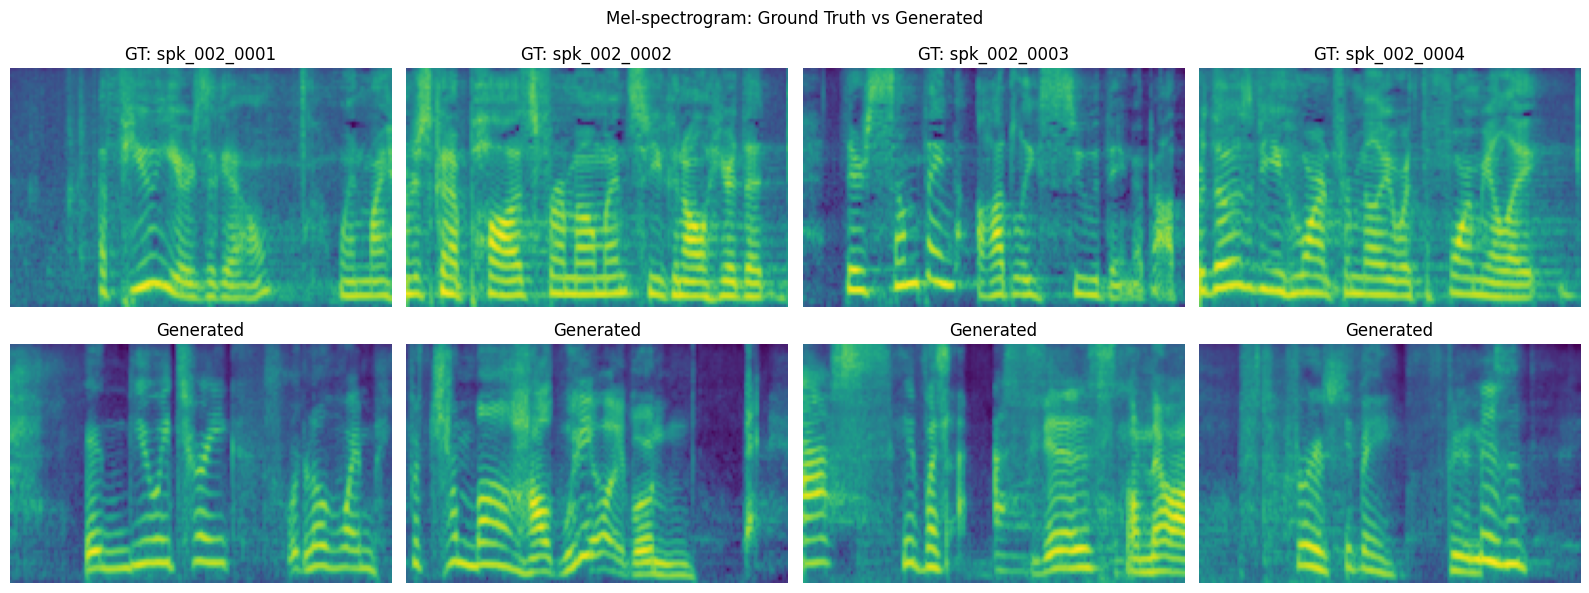

In [30]:
# ── Mel-spec comparison plots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, min(4,N_DEMO), figsize=(16, 6))
for i, rec in enumerate(gen_records[:min(4,N_DEMO)]):
    cid = rec['clip_id']
    gt_mel   = torch.load(MEL_DIR/f'{cid}.wav.spec').numpy()
    # Load generated mel by re-computing from saved WAV
    gen_wav,_ = torchaudio.load(rec['generated'])
    gen_mel   = stft_fn.mel_spectrogram(
                    gen_wav.to(DEVICE)/gen_wav.abs().max().clamp(1e-8)
                ).squeeze(0).cpu().numpy()
    L = min(gt_mel.shape[1], gen_mel.shape[1], 200)
    axes[0,i].imshow(gt_mel[:,:L],aspect='auto',origin='lower')
    axes[0,i].set_title(f'GT: {cid[:15]}')
    axes[1,i].imshow(gen_mel[:,:L],aspect='auto',origin='lower')
    axes[1,i].set_title('Generated')
for ax in axes.flat: ax.axis('off')
plt.suptitle('Mel-spectrogram: Ground Truth vs Generated')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'mel_comparison.png',dpi=120)
plt.show()

## 11. Metrics and Reproducible Evaluation

Run the scriptable Stage 2 evaluator, then load its outputs back into the notebook for inspection.


In [31]:
stage2_eval_script = PIPE_ROOT / 'scripts' / 'stage2_evaluate.py'
stage2_eval_cmd = [
    sys.executable, str(stage2_eval_script),
    '--split', 'test',
    '--demo-count', str(min(10, len(test_df))),
    '--ablation-count', '20',
    '--stage1-summary', str(S1_PRETRAINED_SUMMARY_PATH),
    '--stage1-predictions', str(S1_PRETRAINED_PRED_CSV),
]

full_eval_limit = os.environ.get('PIPELINE_STAGE2_FULL_EVAL_LIMIT')
if full_eval_limit:
    stage2_eval_cmd += ['--full-eval-limit', full_eval_limit]
if os.environ.get('PIPELINE_STAGE2_FAST_EVAL', '0') == '1':
    stage2_eval_cmd.append('--use-fast-inference')
if os.environ.get('PIPELINE_STAGE2_FORCE_EVAL', '0') == '1':
    stage2_eval_cmd.append('--force')

print('Running reproducible Stage 2 evaluation script...')
stage2_eval_result = subprocess.run(stage2_eval_cmd, capture_output=True, text=True, cwd=str(PIPE_ROOT))
print(stage2_eval_result.stdout)
if stage2_eval_result.returncode != 0:
    tail = stage2_eval_result.stderr[-6000:] if stage2_eval_result.stderr else '<no stderr>'
    raise RuntimeError(f'Stage 2 evaluation script failed. Fix the reported runtime/config problem before trusting notebook metrics.\n\n{tail}')


metrics:   0%|          | 0/10 [00:00<?, ?it/s]


STOI: mean=0.1737  std=0.0616
PESQ: mean=1.0365  std=0.0103


,stoi,pesq,clip_id
0,0.124788,1.032154,spk_002_0001
1,0.178303,1.024148,spk_002_0002
2,0.204261,1.025919,spk_002_0003
3,0.252095,1.051672,spk_002_0004
4,0.196983,1.052858,spk_002_0005
5,0.214058,1.037412,spk_002_0006
6,0.221880,1.029966,spk_002_0007
7,0.073571,1.034366,spk_002_0008
8,0.195723,1.046119,spk_002_0009
9,0.075255,1.030061,spk_002_0011


In [32]:
evaluation_summary_path = OUTPUT_DIR / 'evaluation_summary.csv'
final_report_path = OUTPUT_DIR / 'final_report.json'
if not evaluation_summary_path.exists():
    raise FileNotFoundError(f'Missing evaluation summary: {evaluation_summary_path}')
if not final_report_path.exists():
    raise FileNotFoundError(f'Missing final report: {final_report_path}')

eval_summary_df = pd.read_csv(evaluation_summary_path)
final_report = json.loads(final_report_path.read_text())
display(eval_summary_df)
print(json.dumps(final_report, indent=2))


Full test-set E2E evaluation...


test E2E:   0%|          | 0/790 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 12. Evaluation Outputs

Load the CSV outputs emitted by `scripts/stage2_evaluate.py`.


In [ ]:
full_metrics_path = OUTPUT_DIR / 'test_full_metrics.csv'
fixed_guidance_path = OUTPUT_DIR / 'ablation_guidance.csv'
if full_metrics_path.exists():
    full_metrics_df = pd.read_csv(full_metrics_path)
    print(f'Full test metrics rows: {len(full_metrics_df)}')
    display(full_metrics_df.head())
else:
    print(f'Missing full metrics CSV: {full_metrics_path}')

if fixed_guidance_path.exists():
    fixed_guidance_df = pd.read_csv(fixed_guidance_path)
    print('Fixed-guidance ablation:')
    display(fixed_guidance_df)
else:
    print(f'Missing fixed-guidance CSV: {fixed_guidance_path}')


In [ ]:
conf_guidance_path = OUTPUT_DIR / 'ablation_conf_weighted.csv'
failure_buckets_path = OUTPUT_DIR / 'failure_buckets.csv'
if conf_guidance_path.exists():
    conf_guidance_df = pd.read_csv(conf_guidance_path)
    print('Confidence-weighted guidance:')
    display(conf_guidance_df.head())
else:
    print('Confidence-weighted guidance skipped or not credible enough to run.')

if failure_buckets_path.exists():
    failure_buckets_df = pd.read_csv(failure_buckets_path)
    print('Failure buckets:')
    display(failure_buckets_df)


In [ ]:
summary_table_path = OUTPUT_DIR / 'evaluation_summary.csv'
if summary_table_path.exists():
    summary_table_df = pd.read_csv(summary_table_path)
    display(summary_table_df)

print('Final report path:', final_report_path)
